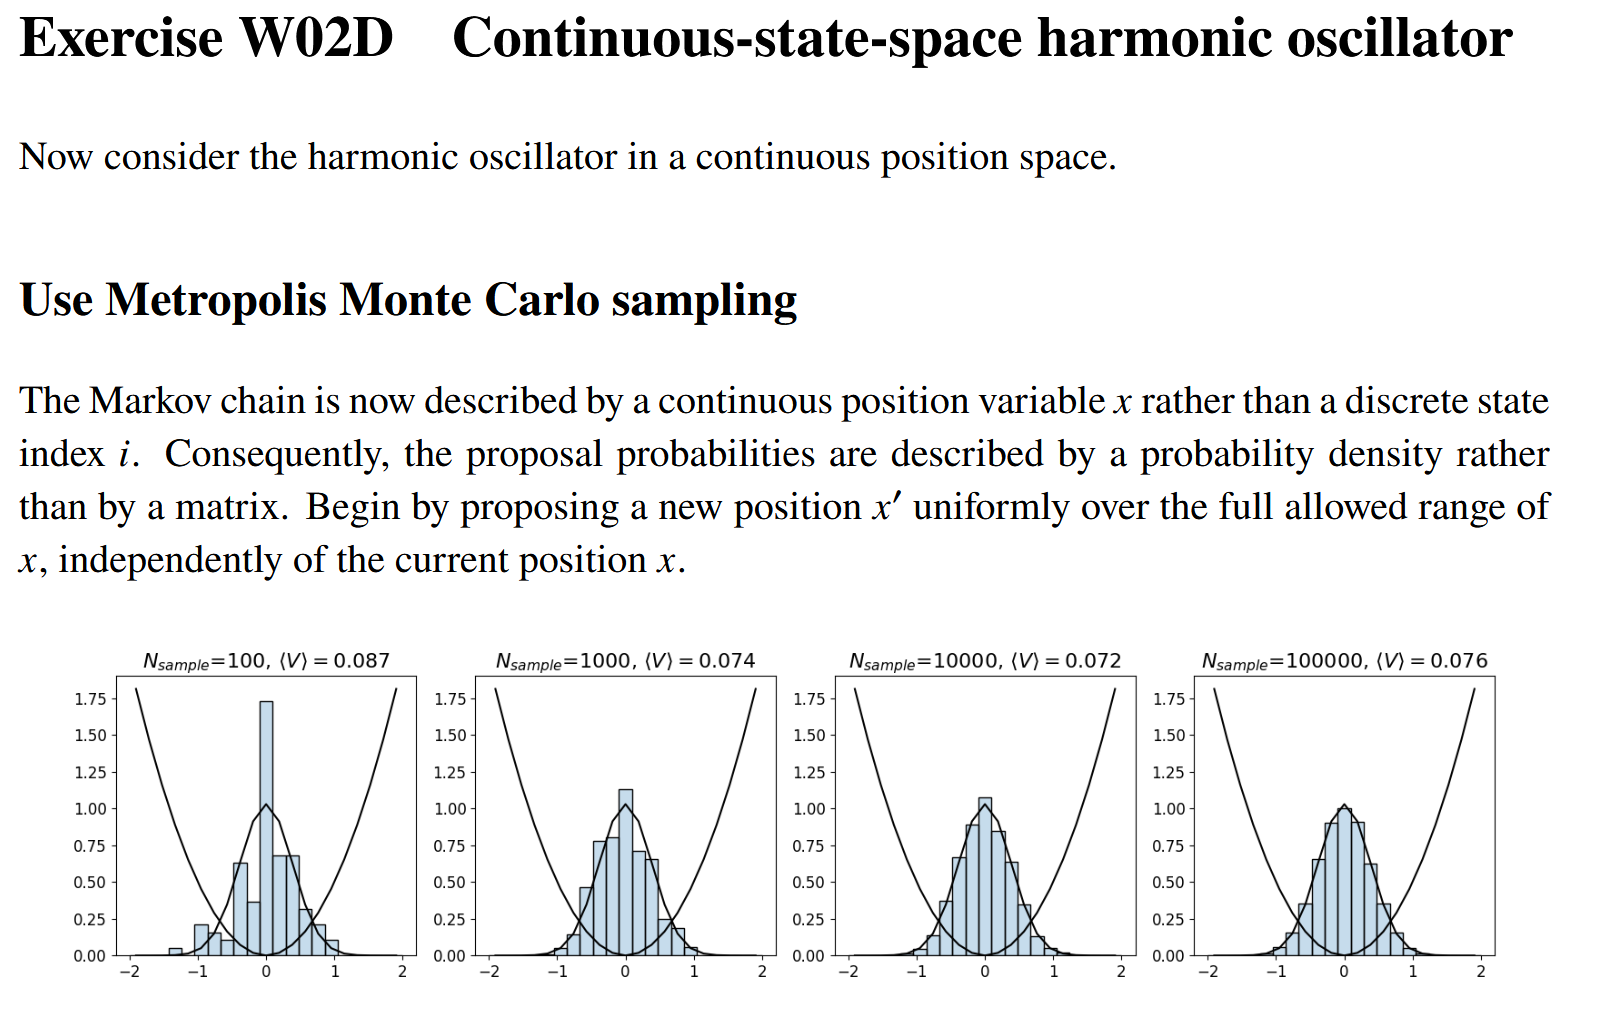

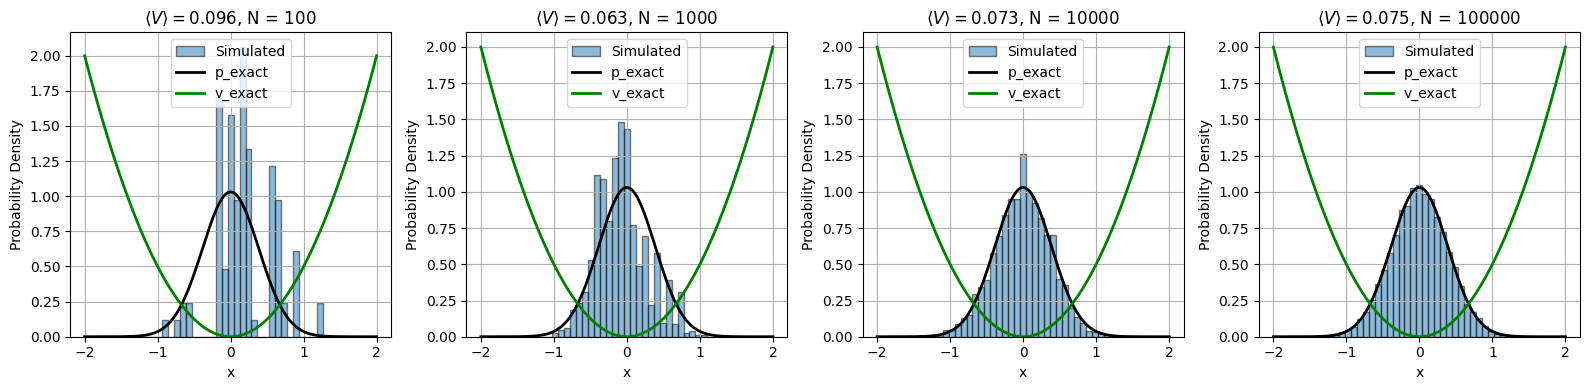

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

class HarmonicOscilator:
    def __init__(self, k=1, x0=0, kbT=0.15, xmin=-2, xmax=2, start=0):
        self.k = k
        self.x0 = x0
        self.state = start
        self.kbT = kbT
        self.xmin = xmin
        self.xmax = xmax

    def V(self, x):
        return (0.5*self.k*(x-self.x0)**2) 


class ContinuousMetro(HarmonicOscilator):
    def propose(self):
        return np.random.uniform(self.xmin, self.xmax)

    def step(self):
        x_m = self.propose()
        A = min(1.0, self._exp(self.state, x_m))
        if np.random.rand() < A:
            self.state = x_m

    def run_simulation(self, n=100_000):
        """
        Run simulation returns evaluate P ndarray
        """
        self.n = n
        counts = [self.state]
        for _ in range(n):
            self.step()
            counts.append(self.state)

        self.P = np.array(counts)
        return self.P

    def _exp(self, x, y):
        """
        Calculates the ratio P_j/P_i
        """
        return np.exp(-1/self.kbT * (self.V(y) - self.V(x)))

    def plot(self , ax):
        if not np.any(self.P): 
            raise Exception('Simulation not run')

        bin_edges = np.linspace(self.xmin, self.xmax, 50)
        ax.hist(self.P, bins=bin_edges, density=True, facecolor='C0', alpha=0.5, edgecolor='k', label='Simulated')

        x_grid = np.linspace(self.xmin, self.xmax, 200)
        v_exact = self.V(x_grid)
        unnormalized_p = np.exp(-v_exact / self.kbT)
        Z, _ = quad(lambda x: np.exp(-self.V(x) / self.kbT), self.xmin, self.xmax)
        p_exact = unnormalized_p / Z
        ax.plot(x_grid, p_exact, 'k-', lw=2, label='p_exact')
        ax.plot(x_grid, v_exact, 'g-', lw=2, label='v_exact')

        ax.set_xlabel('x')
        ax.set_ylabel('Probability Density')
        ax.grid(True)
        ax.set_title(r'$\langle V\rangle=$' + f'{self.thermal_avg_V():.3f}, N = {self.n}')
        ax.legend()

    def thermal_avg_V(self):
        if not np.any(self.P): 
            raise Exception('Simulation not run')

        return np.mean(self.V(self.P))


runs = [100, 1000, 10_000, 100_000]
fig, axs = plt.subplots(1, len(runs), figsize=(len(runs)*4, 4))

for i in range(len(runs)):
    sim = ContinuousMetro()
    sim.run_simulation(runs[i])
    sim.plot(axs[i])

plt.tight_layout()
plt.show()


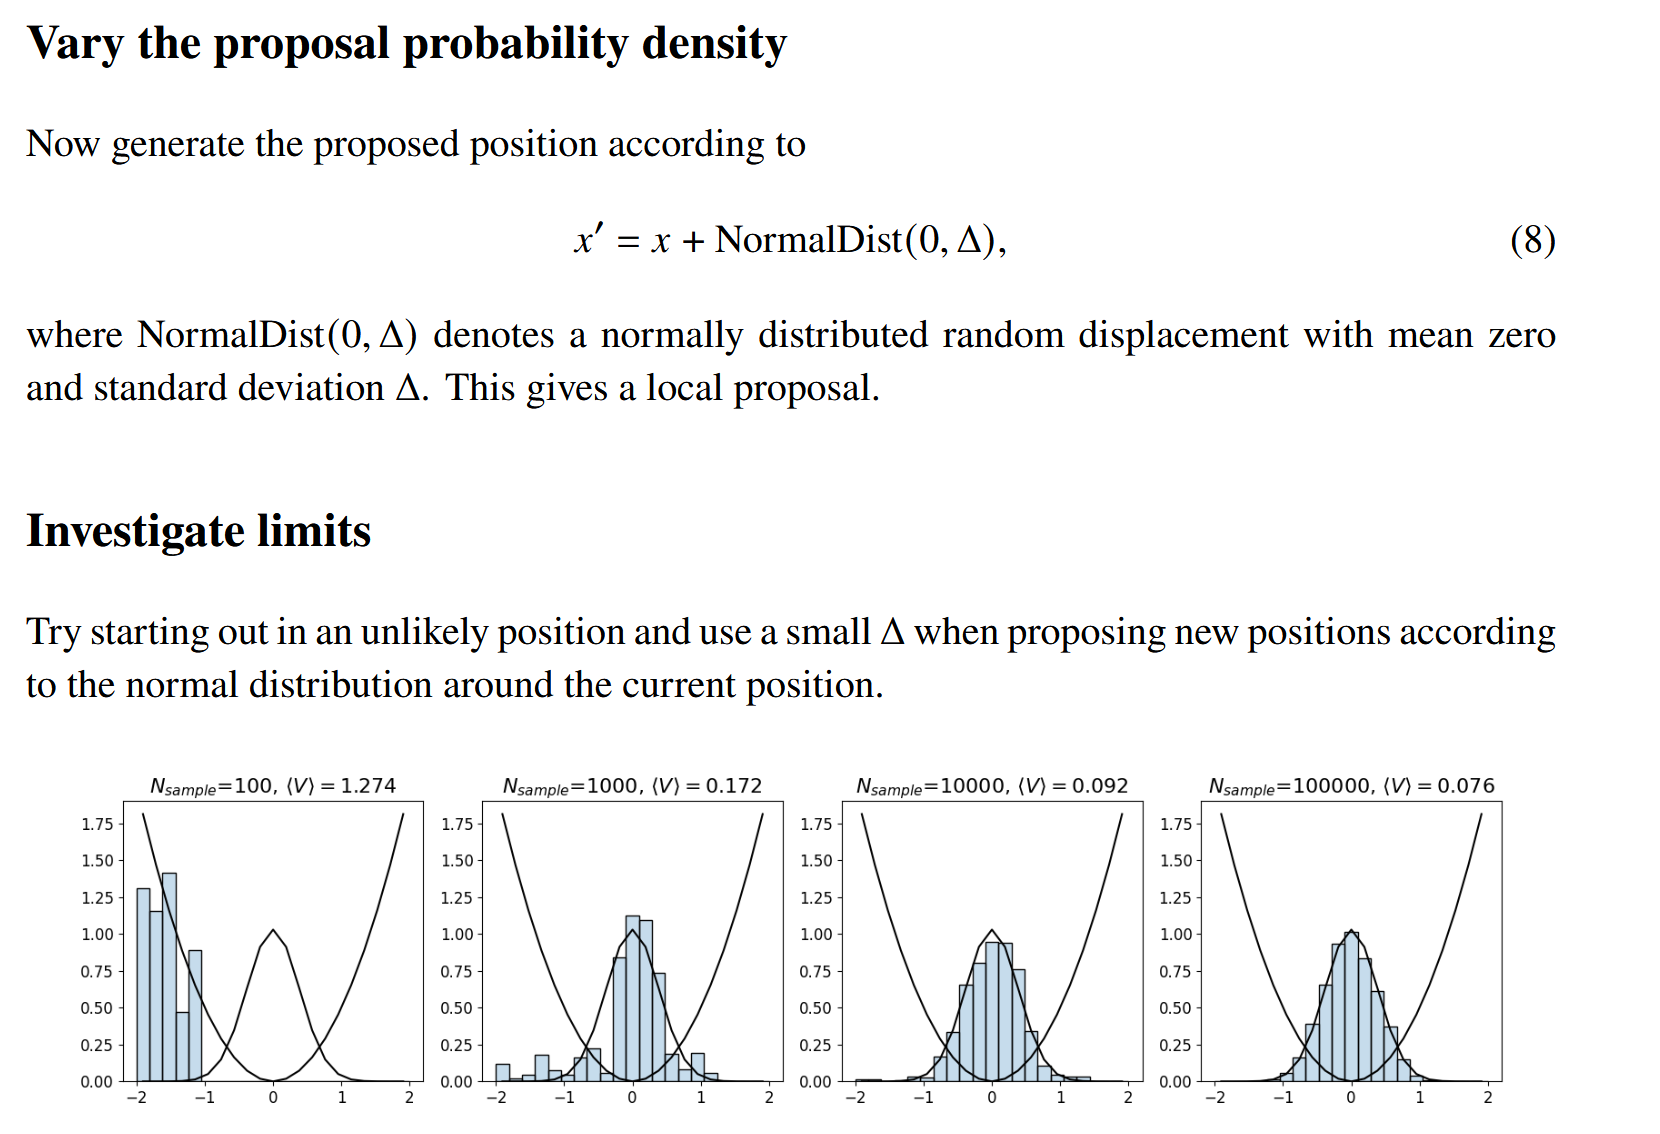

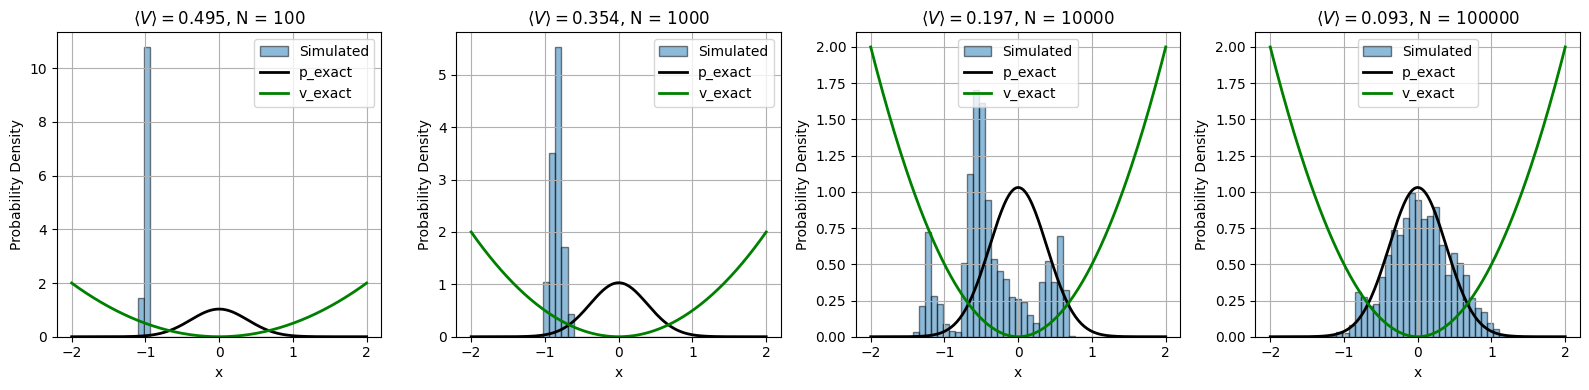

In [69]:
class ContinuousMetro(ContinuousMetro):
    def propose(self):
        return self.state + np.random.normal(0, 0.01)

runs = [100, 1000, 10_000, 100_000]
fig, axs = plt.subplots(1, len(runs), figsize=(len(runs)*4, 4))

for i in range(len(runs)):
    sim = ContinuousMetro(start=-1)
    sim.run_simulation(runs[i])
    sim.plot(axs[i])

plt.tight_layout()
plt.show()

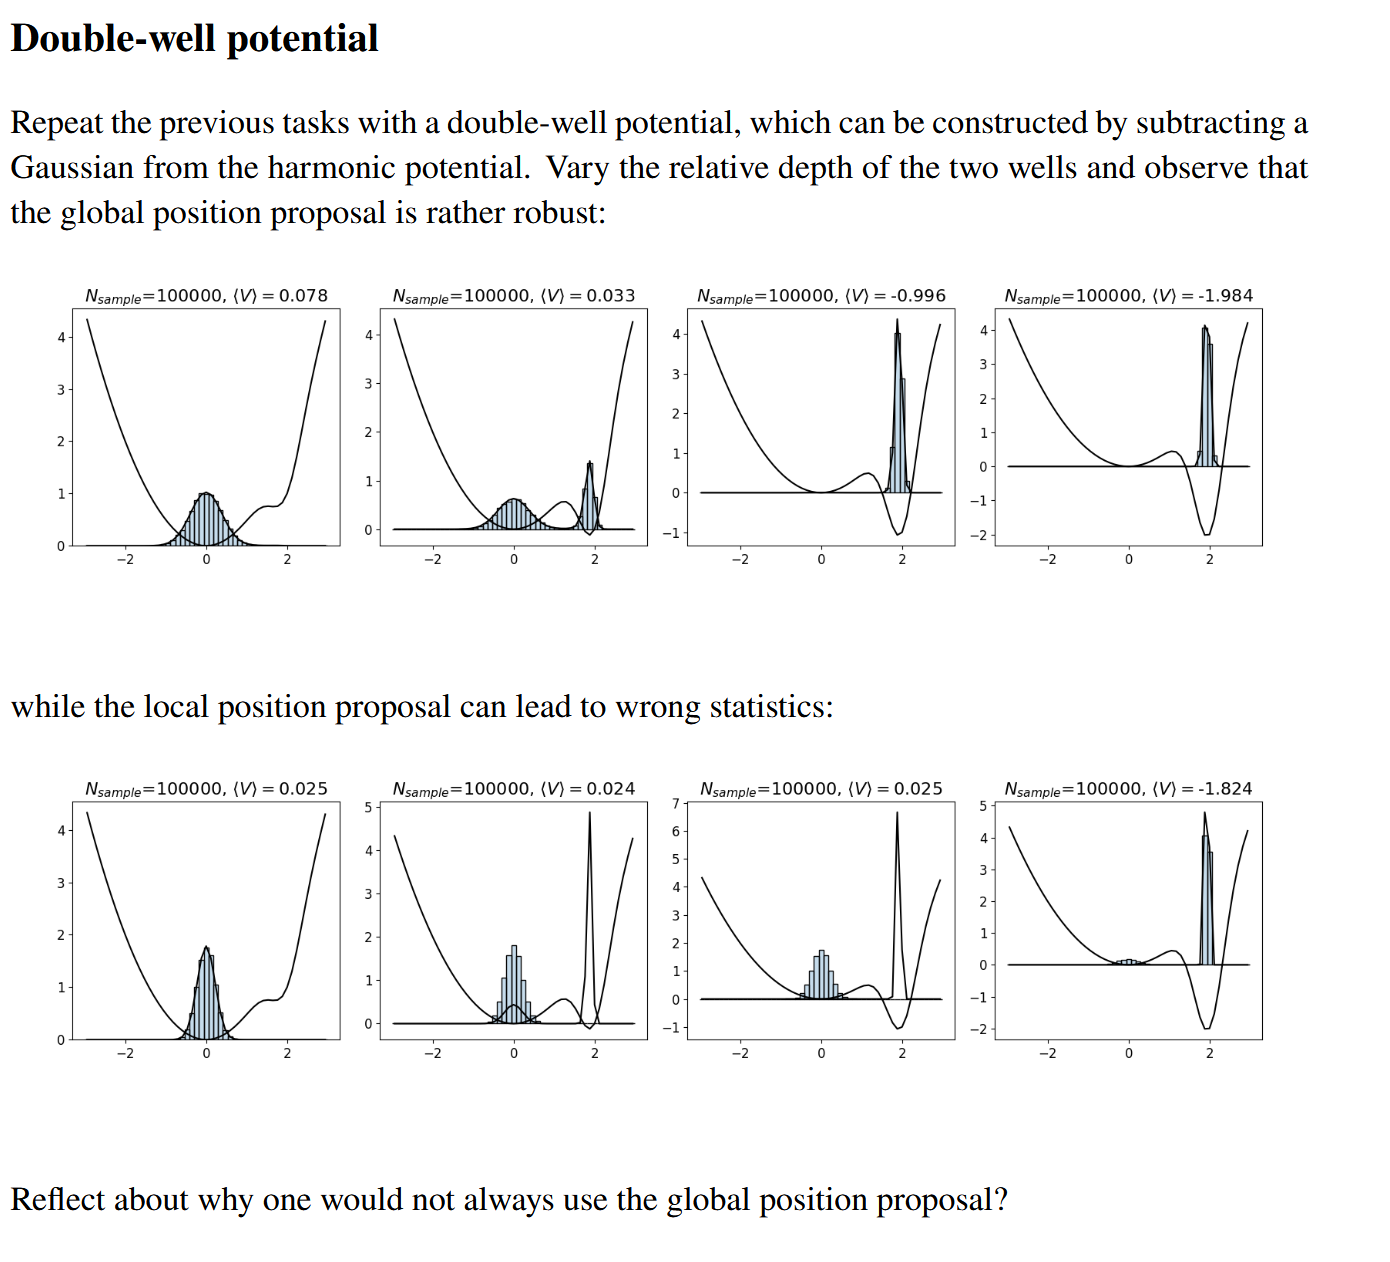

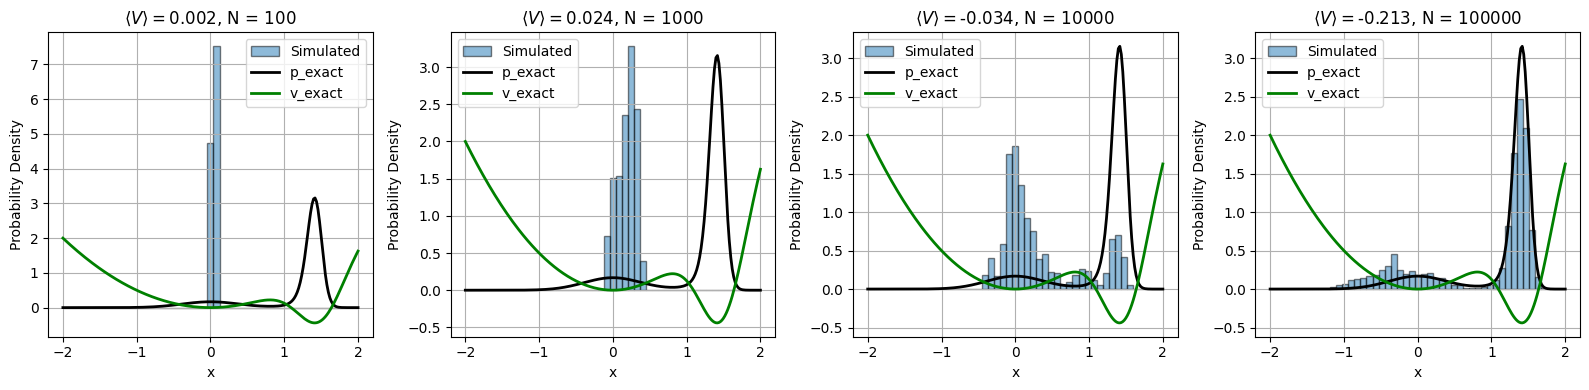

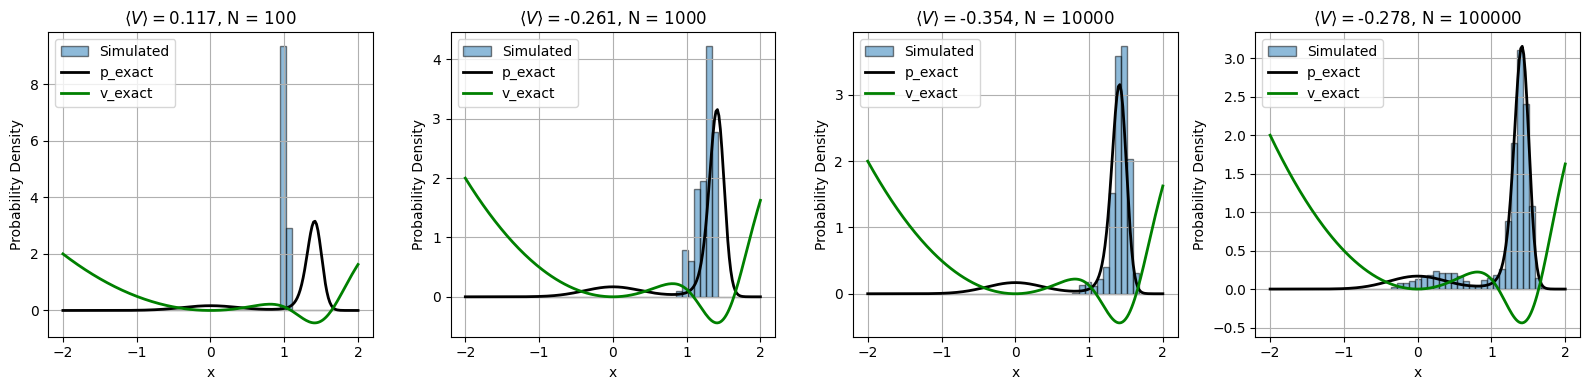

In [70]:
class ContinuousMetro(ContinuousMetro):
    def V(self, x):
        return 1/2*self.k*x**2 - 1.5*np.exp(-(x - 1.5)**2/(2*0.3**2))

runs = [100, 1000, 10_000, 100_000]
fig, axs = plt.subplots(1, len(runs), figsize=(len(runs)*4, 4))

for i in range(len(runs)):
    sim = ContinuousMetro()
    sim.run_simulation(runs[i])
    sim.plot(axs[i])

plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, len(runs), figsize=(len(runs)*4, 4))

for i in range(len(runs)):
    sim = ContinuousMetro(start=1)
    sim.run_simulation(runs[i])
    sim.plot(axs[i])

plt.tight_layout()
plt.show()